## EDA
### Demographic & Customer Profile Analysis

In [2]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Load the cleaned data
df = pd.read_csv("../data/processed/cleaned_telco_customer_churn.csv")

print(df.shape)
df.head()

(7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Does churn vary by gender?
Analyzing churn rates between male and female customers to identify any significant differences.

In [4]:
gender_wise_churn_rate = df.groupby(by='gender')['Churn'].value_counts(normalize=True).round(2).to_frame()
gender_wise_churn_rate

proportion
gender Churn            
Female No           0.73
       Yes          0.27
Male   No           0.74
       Yes          0.26

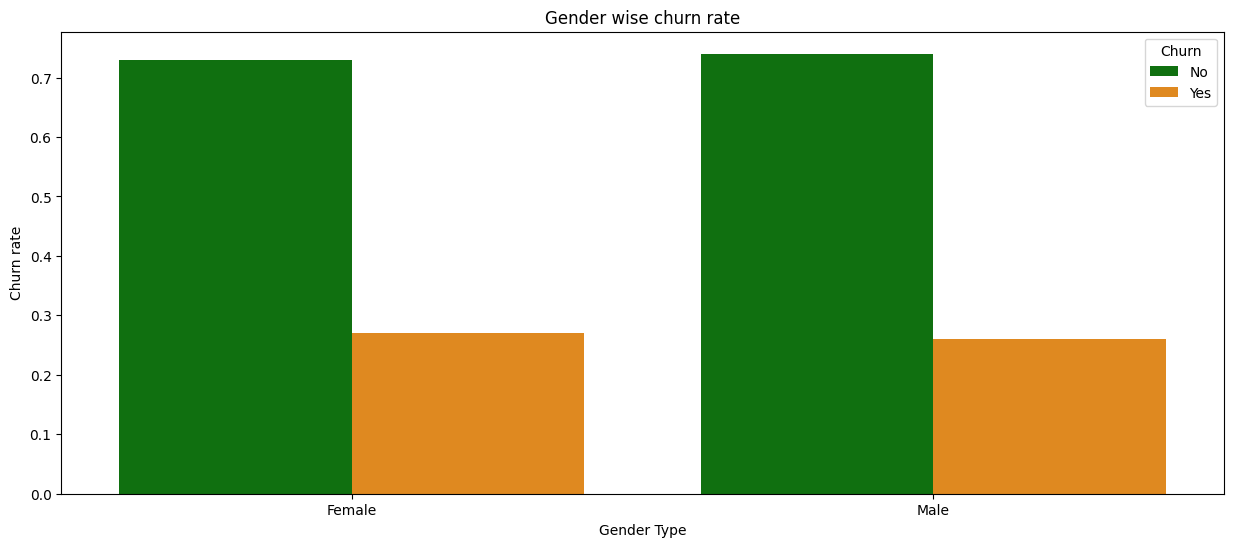

In [4]:
## Visualize
plt.figure(figsize=(15,6))
sns.barplot(data=gender_wise_churn_rate, x='gender', y='proportion', hue='Churn', palette=['green', 'darkorange'] )
plt.title('Gender wise churn rate')
plt.xlabel('Gender Type')
plt.ylabel('Churn rate')
plt.show()

#### Comment:
Churn rate varies with gender but not so much. The churn rate for female (27%) is slighly higher than male(26%) customers. 

### 2. Are senior citizens more likely to churn?
Analyzing churn rates among senior citizens compared to other age groups to determine if age is a significant factor in customer retention.

In [5]:
age_wise_churn_rate = df.groupby(by='SeniorCitizen')['Churn'].value_counts(normalize=True).round(2).to_frame()
age_wise_churn_rate

proportion
SeniorCitizen Churn            
0             No           0.76
              Yes          0.24
1             No           0.58
              Yes          0.42

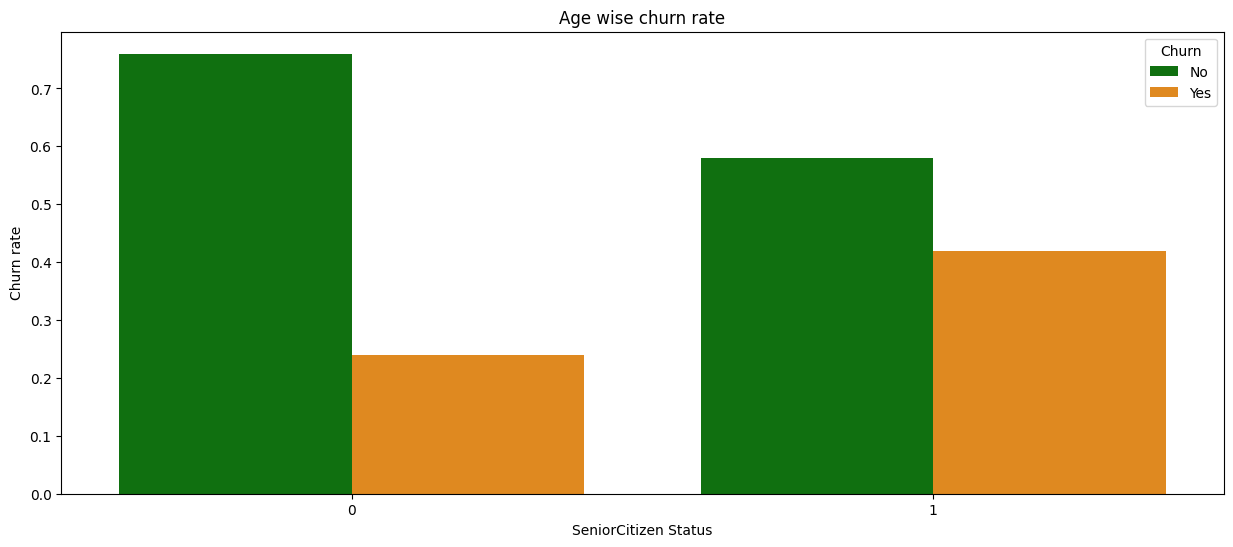

In [6]:
## Visualize
plt.figure(figsize=(15,6))
sns.barplot(data=age_wise_churn_rate, x='SeniorCitizen', y='proportion', hue='Churn', palette=['green', 'darkorange'] )
plt.title('Age wise churn rate')
plt.xlabel('SeniorCitizen Status')
plt.ylabel('Churn rate')
plt.show()

#### Comment:
This analysis indicates that senior citizens have a higher churn rate of approximately 42%, compared to 24% for non-senior customers. This suggests that age may play a role in customer retention, and targeted strategies may be needed to address the specific needs and concerns of senior customers.

### 3. How does churn differ for customers with partners or dependents?
Customers with partners or dependents may have different needs and priorities, which can influence their likelihood of churning. Understanding these differences can help tailor retention strategies to specific customer segments.


In [7]:
## Churn rate of customers based on partner
partner_wise_churn_rate = df.groupby(by='Partner')['Churn'].value_counts(normalize=True).round(2).to_frame()
partner_wise_churn_rate

proportion
Partner Churn            
No      No           0.67
        Yes          0.33
Yes     No           0.80
        Yes          0.20

In [8]:
## Churn rate of customers based on denpendencies
dependent_wise_churn_rate = df.groupby(by='Dependents')['Churn'].value_counts(normalize=True).round(2).to_frame()
dependent_wise_churn_rate

proportion
Dependents Churn            
No         No           0.69
           Yes          0.31
Yes        No           0.84
           Yes          0.16

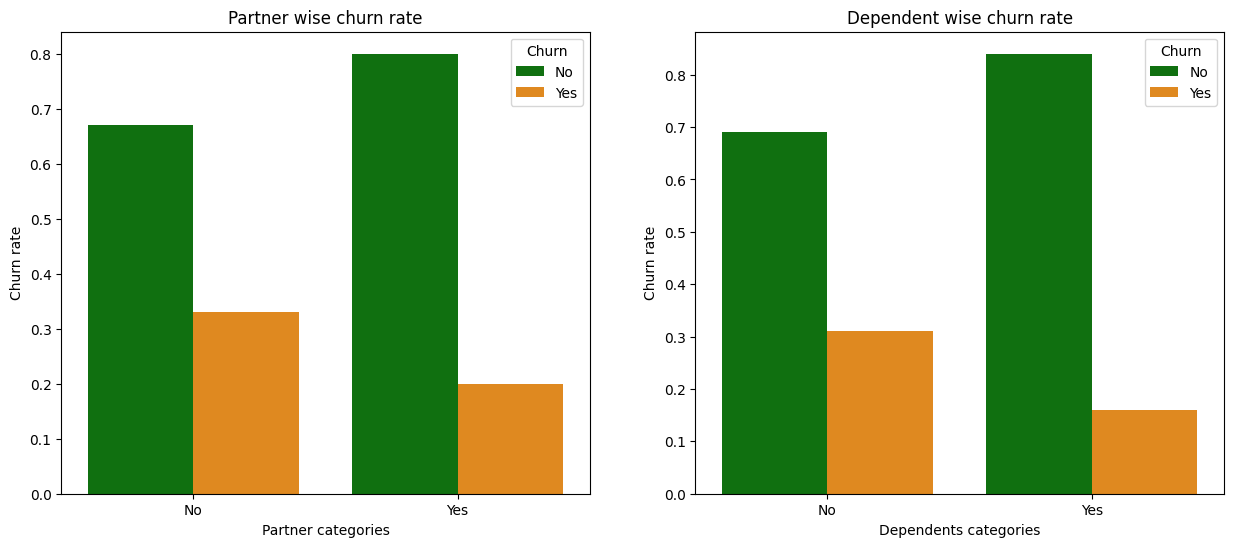

In [9]:
## Visualization
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.barplot(data=partner_wise_churn_rate, x='Partner', y='proportion', hue='Churn', palette=['green', 'darkorange'] )
plt.title('Partner wise churn rate')
plt.xlabel('Partner categories')
plt.ylabel('Churn rate')

plt.subplot(1,2,2)
sns.barplot(data=dependent_wise_churn_rate, x='Dependents', y='proportion', hue='Churn', palette=['green', 'darkorange'] )
plt.title('Dependent wise churn rate')
plt.xlabel('Dependents categories')
plt.ylabel('Churn rate')

plt.show()

#### Comment:
* This analysis shows that customer without partners  and without dependents have a higher churn rate.
* Churn rate for customers without partners is approximately 33%
* Churn rate for customers without dependencis is approximately 31%

### 4. Which demographic group has the highest churn probability?
Understanding churn rates across different demographic groups (gender, SeniorCitizen, Partner, Dependents).

In [11]:
demographic_groups_wise_churn=pd.pivot_table(data=df, index=['gender', 'SeniorCitizen', 'Partner', 'Dependents'], columns=['Churn'], aggfunc='size')
demographic_groups_wise_churn

Churn                                     No  Yes
gender SeniorCitizen Partner Dependents          
Female 0             No      No          909  428
                             Yes         110   32
                     Yes     No          482  113
                             Yes         710  124
       1             No      No          159  158
                             Yes           2    1
                     Yes     No          136   73
                             Yes          31    8
Male   0             No      No          962  418
                             Yes         166   43
                     Yes     No          438  128
                             Yes         713  105
       1             No      No          126  117
                             Yes           4    1
                     Yes     No          176  105
                             Yes          31   12

In [39]:
groupwise_churn_probability = round(demographic_groups_wise_churn['Yes']/(demographic_groups_wise_churn['Yes']+demographic_groups_wise_churn['No']), 2).to_frame().reset_index().sort_values(ascending=False, by=[0]).reset_index(drop='index')

groupwise_churn_probability.rename(columns={0 : 'churn_probability'}, inplace=True)

groupwise_churn_probability

,gender,SeniorCitizen,Partner,Dependents,churn_probability
0,Female,1,No,No,0.50
1,Male,1,No,No,0.48
2,Male,1,Yes,No,0.37
3,Female,1,Yes,No,0.35
4,Female,1,No,Yes,0.33
5,Female,0,No,No,0.32
6,Male,0,No,No,0.30
7,Male,1,Yes,Yes,0.28
8,Male,0,Yes,No,0.23
9,Female,0,No,Yes,0.23


#### Comment:
* There are 16 possibe demographic groups of churned customers.
* Among these groups, the one with the highest churn probability is (**Gender: Female, SeniorCitizen: Yes, Partner: No, Dependents: No**) with a churn probability of 50%.
* So, this demographic group has the highest churn probability compared to other groups.

### 5. Is there a demographic segment that is low churn but high revenue?


In [52]:
## Function to get churn rate
churn_rate = lambda x: round((x == 'Yes').sum()/len(x), 2)

## Calculate group wise churn rate and total revenue
demographic_segment_with_revenue = df.groupby(['gender', 'SeniorCitizen', 'Dependents', 'Partner']).agg(
    Churn_Rate=('Churn', churn_rate),
    Total_Revenue=('TotalCharges', 'sum')
).reset_index()

demographic_segment_with_revenue.sort_values(by=['Churn_Rate', 'Total_Revenue'], ascending=[True, False])

,gender,SeniorCitizen,Dependents,Partner,Churn_Rate,Total_Revenue
11,Male,0,Yes,Yes,0.13,2240010.55
3,Female,0,Yes,Yes,0.15,2184824.60
1,Female,0,No,Yes,0.19,1880579.45
14,Male,1,Yes,No,0.20,9422.55
10,Male,0,Yes,No,0.21,291730.55
7,Female,1,Yes,Yes,0.21,146323.50
9,Male,0,No,Yes,0.23,1913301.85
2,Female,0,Yes,No,0.23,176903.35
15,Male,1,Yes,Yes,0.28,181176.05
8,Male,0,No,No,0.30,2053247.35


#### Comment:
The above analysis shows that Demographic segment with **gender: male, SeniorCitizen: No, Dependents: yes, Partner: Yes** has **low churn** (churn_rate=13%) but **high revenue** (total_revenue = 2240010.55). This segment could be targeted for upselling or cross-selling opportunities to further enhance revenue while maintaining low churn rates.

## Conclusion from Demographic Analysis
From this demographic analysis of customers it is clear that the customer group (**Gender: Female, SeniorCitizen: Yes, Partner: No, Dependents: No**) has the highest churn probability and that is almost 50%. That means 50 out of 100 customers of this group are churning out.

On the ohter hand, customer group **gender: male, SeniorCitizen: No, Dependents: yes, Partner: Yes** has **low churn** (churn_rate=13%) but **high revenue** (total_revenue = 2240010.55). This group can be targeted for upselling.

---
### 👨‍💻 Author Information
**Name:** [Amaresh Maity]  
**Date:** 2026-01-07  
**Role:** [Data Scientist | AI Engineer]



#### Let's Connect!

If you have questions about this analysis or would like to collaborate, feel free to reach out:

* **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/amareshmaity/)
* **GitHub:** [@amareshmaity](https://github.com/amareshmaity)
* **Email:** [contacttoamaresh@gmail.com](mailto:contacttoamaresh@gmail.com)
